# SIT720 11.1HD — Machine Learning Mini Research

## Part 1: Understanding and Reproducing the Published Study

### Selected Research Paper

**An efficient stacking-based ensemble technique for early heart attack prediction**

This study investigates the use of multiple machine learning classification
methods for heart disease prediction and proposes a stacking-based ensemble
approach to improve predictive performance.

The reproduction study aims to implement the methodology described in the
published paper using the same dataset and feature set where the information
is available. The reproduced models will be evaluated using Accuracy,
Precision, Recall, F1 Score and AUC, followed by a comparison with the
published results.

Where implementation details are not sufficiently specified in the
published paper, reasonable assumptions will be explicitly documented and
justified.

In [3]:
# ============================================================
# SIT720 11.1HD
# Part 1: Published Paper Reproduction
# Dataset Loading and Initial Verification
# ============================================================

import os
import numpy as np
import pandas as pd

# Path to the uploaded dataset
DATA_PATH = "heart.csv"

# Check that the dataset exists
if not os.path.exists("heart.csv"):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

# Load the dataset
df = pd.read_csv("heart.csv")

# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget class distribution:")
print(df["target"].value_counts().sort_index())

print("\nFirst five rows:")
display(df.head())

Dataset loaded successfully.
Dataset shape: 1025 rows × 14 columns

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target class distribution:
target
0    499
1    526
Name: count, dtype: int64

First five rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Initial Dataset Observations

The dataset contains **1,025 records and 14 columns**, consisting of
**13 predictor variables and one binary target variable**.

The predictor variables represent demographic and clinical attributes
including age, sex, chest pain type, resting blood pressure, cholesterol,
fasting blood sugar, resting ECG results, maximum heart rate,
exercise-induced angina, ST depression, slope, number of major vessels and
thalassemia.

The target variable is binary, where **0 represents no heart disease and
1 represents the presence of heart disease**.

No missing values were identified in the supplied dataset. Therefore, no
imputation is required for the loaded data at this stage. The dataset is
approximately balanced, containing **499 observations for class 0 and 526
observations for class 1**.

The selected features correspond to the 14 attributes described in the
published paper. 

## Data Preparation and Train/Test Split

The published study reports preprocessing that includes handling missing
values, scaling/normalisation, and encoding categorical variables before
dividing the dataset into training and testing sets.

For the supplied dataset, all 14 variables are already numerically encoded
and no missing values are present. Therefore, no additional categorical
encoding or missing-value imputation is required.

The paper does not explicitly state the exact train/test split ratio or
random seed in the available methodology. However, the published accuracy
values correspond closely to a test set of approximately 20% of the 1,025
observations (205 records). Therefore, an 80/20 stratified split is used
here as a documented reproduction assumption.

Standardisation is fitted only on the training data and then applied to the
test data to avoid information leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate predictors and target
X = df.drop(columns=["target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain/Test Split")
print("----------------")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

# Feature standardisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier inspection
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("\nScaled training data:")
display(X_train_scaled.head())

print("\nScaled test data:")
display(X_test_scaled.head())

print("\nScaled training feature means:")
print(X_train_scaled.mean().round(4))

print("\nScaled training feature standard deviations:")
print(X_train_scaled.std().round(4))

Feature matrix shape: (1025, 13)
Target shape: (1025,)

Train/Test Split
----------------
Training samples: 820
Testing samples:  205

Training class distribution:
target
0    399
1    421
Name: count, dtype: int64

Testing class distribution:
target
0    100
1    105
Name: count, dtype: int64

Scaled training data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
4,0.811626,-1.509967,-0.909572,0.314729,0.895791,2.346899,0.926946,-1.921155,-0.718131,0.696525,-0.597542,2.207301,-0.562451
688,0.152247,-1.509967,-0.909572,3.767643,0.779115,2.346899,-0.982842,-0.725362,1.392504,2.475810,-2.198799,1.228400,1.090630
477,0.262144,0.662266,1.048037,-0.242193,-0.368191,-0.426094,-0.982842,0.027545,-0.718131,-0.574393,-0.597542,0.249500,1.090630
336,0.262144,0.662266,1.048037,0.983035,-2.371116,2.346899,0.926946,1.046184,-0.718131,-0.743849,1.003715,0.249500,1.090630
960,-0.287339,-1.509967,1.048037,0.203344,-1.009905,-0.426094,-0.982842,0.869030,-0.718131,-0.828577,-0.597542,-0.729400,-0.562451



Scaled test data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
756,1.031419,0.662266,-0.909572,-0.687730,-0.037611,-0.426094,-0.982842,-2.364041,1.392504,0.950709,-2.198799,0.2495,-0.562451
353,0.262144,0.662266,-0.909572,-1.244652,-0.912675,-0.426094,0.926946,-1.035382,1.392504,0.357614,-0.597542,-0.7294,-2.215532
929,0.591833,0.662266,-0.909572,-0.130809,-0.815446,-0.426094,-0.982842,-0.769650,1.392504,1.120164,-0.597542,1.2284,1.090630
129,0.262144,0.662266,-0.909572,0.426113,-1.087688,-0.426094,0.926946,-0.061032,-0.718131,-0.574393,-0.597542,-0.7294,-2.215532
591,0.921523,-1.509967,-0.909572,-1.356036,0.409644,-0.426094,0.926946,0.869030,1.392504,0.611797,-0.597542,1.2284,-0.562451



Scaled training feature means:
age        -0.0
sex         0.0
cp          0.0
trestbps    0.0
chol       -0.0
fbs        -0.0
restecg    -0.0
thalach     0.0
exang      -0.0
oldpeak     0.0
slope      -0.0
ca          0.0
thal       -0.0
dtype: float64

Scaled training feature standard deviations:
age         1.0006
sex         1.0006
cp          1.0006
trestbps    1.0006
chol        1.0006
fbs         1.0006
restecg     1.0006
thalach     1.0006
exang       1.0006
oldpeak     1.0006
slope       1.0006
ca          1.0006
thal        1.0006
dtype: float64


## Reproduction Models

The published study evaluates six individual classification algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extreme Gradient Boosting (XGBoost)
5. Naive Bayes
6. K-Nearest Neighbours (KNN)

These models are reproduced using the same 13 predictor variables. The
preprocessed training data are used to fit each classifier, while the test
set is kept separate for final evaluation.

The paper reports Accuracy, Precision, Recall, F1 Score and AUC among its
evaluation measures. These metrics are therefore calculated for every
reproduced classifier.

In [7]:

# Individual Classification Models
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Define the six classifiers
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier()
}

print("Models prepared successfully:\n")

for name in models:
    print(f"- {name}")

Models prepared successfully:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- KNN


In [8]:
# Model Training
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # KNN and Logistic Regression benefit from the scaled data,
    # while the tree-based models are also trained on the same
    # preprocessed feature set for consistency.
    model.fit(X_train_scaled, y_train)
    
    trained_models[name] = model
    
    print(f"{name} trained successfully.\n")

print("All six models have been trained.")

Training Logistic Regression...
Logistic Regression trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training XGBoost...
XGBoost trained successfully.

Training Naive Bayes...
Naive Bayes trained successfully.

Training KNN...
KNN trained successfully.

All six models have been trained.


## Evaluation of the Reproduced Classifiers

The trained models are evaluated on the held-out test set.

The following metrics are calculated:

- **Accuracy** — proportion of all predictions that are correct.
- **Precision** — proportion of predicted positive cases that are actually positive.
- **Recall** — proportion of actual positive cases correctly identified.
- **F1 Score** — harmonic mean of precision and recall.
- **AUC** — area under the ROC curve, measuring the model's ability to
  distinguish between the two target classes across classification thresholds.

The test set is used only for final evaluation and was not used during model
training.

In [9]:
# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    # Class predictions
    y_pred = model.predict(X_test_scaled)

    # Probability estimates for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # Fallback for models without predict_proba
        y_score = model.decision_function(X_test_scaled)
        y_prob = y_score

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Display rounded results
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUC"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

display(results_display)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629


## Duplicate Records and Reproduction Validity

The initial reproduction produced unusually high performance for the
tree-based ensemble models, including 100% accuracy for Random Forest and
XGBoost.

Because such results differ substantially from the published study, the
dataset was investigated for duplicate observations.

This check is important because a random train/test split can place
identical observations in both subsets. In that situation, a model may
effectively encounter the same feature pattern during training and testing,
leading to artificially inflated test performance.

The duplicate analysis therefore examines:

1. Exact duplicate rows in the complete dataset.
2. Duplicate predictor rows while excluding the target.
3. The number of test observations whose predictor values also occur in
   the training set.

These checks are used to assess whether data leakage may explain the
difference between the reproduction results and the published results.

In [11]:

# Duplicate Records and Potential Data Leakage
# 1. Exact duplicate rows

exact_duplicates = df.duplicated().sum()



# 2. Duplicate predictor rows
feature_columns = [col for col in df.columns if col != "target"]

print(f"Feature columns: {feature_columns}")

duplicate_features = df.duplicated(
    subset=feature_columns).sum()

# Check whether duplicated feature patterns have conflicting labels
label_counts = (
    df.groupby(feature_columns)["target"]
    .nunique()
)

conflicting_duplicates = (label_counts > 1).sum()


# 3. Test/train feature overlap

train_feature_tuples = set(
    map(tuple, X_train.to_numpy())
)

test_train_overlap = sum(
    tuple(row) in train_feature_tuples
    for row in X_test.to_numpy()
)

# Display findings
print("Duplicate and Leakage Analysis")
print("--------------------------------")

print(f"Total observations: {len(df)}")
print(f"Exact duplicate rows: {exact_duplicates}")
print(
    f"Exact duplicate percentage: "
    f"{100 * exact_duplicates / len(df):.2f}%"
)

print(f"\nDuplicate predictor rows: {duplicate_features}")

print(
    "Duplicate predictor groups with conflicting target labels: "
    f"{conflicting_duplicates}"
)

print(
    f"\nTest observations whose feature values also appear in training: "
    f"{test_train_overlap} / {len(X_test)}"
)

print(
    f"Test/train feature overlap: "
    f"{100 * test_train_overlap / len(X_test):.2f}%"
)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Duplicate and Leakage Analysis
--------------------------------
Total observations: 1025
Exact duplicate rows: 723
Exact duplicate percentage: 70.54%

Duplicate predictor rows: 723
Duplicate predictor groups with conflicting target labels: 0

Test observations whose feature values also appear in training: 202 / 205
Test/train feature overlap: 98.54%


## Leakage-Controlled Sensitivity Analysis

The initial random train/test split resulted in substantial overlap between
training and test predictor patterns. This can inflate predictive performance
because the model may encounter an identical feature vector during training.

To investigate the effect, a leakage-controlled sensitivity analysis is
performed by removing exact duplicate predictor rows before creating a new
train/test split.

This analysis is not presented as the exact procedure used by the authors,
because the paper does not specify whether duplicate observations were
removed. Instead, it is used to assess the robustness of the reproduction
and to explain discrepancies between the reproduced and published results.

The same 13 predictor variables, standardisation procedure, classifier
families and evaluation metrics are retained.

In [16]:
# Leakage-Controlled Sensitivity Experiment
# Remove duplicate predictor patterns

df_unique = df.drop_duplicates(
    subset=feature_columns
).copy()

print("Original dataset size:", df.shape)
print("Leakage-controlled dataset size:", df_unique.shape)

print(
    f"\nRemoved {len(df) - len(df_unique)} duplicated observations."
)

print(
    f"Unique predictor patterns retained: {len(df_unique)}"
)


# Separate features and target
X_unique = df_unique[feature_columns]
y_unique = df_unique["target"]

print("\nClass distribution after duplicate removal:")
print(y_unique.value_counts().sort_index())


# Stratified 80/20 split
X_unique_train, X_unique_test, y_unique_train, y_unique_test = (
    train_test_split(
        X_unique,
        y_unique,
        test_size=0.20,
        stratify=y_unique,
        random_state=42
    )
)

print("\nLeakage-Controlled Split")
print("------------------------")
print(f"Training samples: {len(X_unique_train)}")
print(f"Testing samples:  {len(X_unique_test)}")


# Standardisation
unique_scaler = StandardScaler()

X_unique_train_scaled = unique_scaler.fit_transform(
    X_unique_train
)

X_unique_test_scaled = unique_scaler.transform(
    X_unique_test
)

# Train and evaluate the same six classifiers

unique_results = []

for name, model in models.items():

    model.fit(
        X_unique_train_scaled,
        y_unique_train
    )

    y_pred = model.predict(
        X_unique_test_scaled
    )

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_unique_test_scaled
        )[:, 1]
    else:
        y_prob = model.decision_function(
            X_unique_test_scaled
        )

    unique_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_unique_test,
            y_pred
        ),
        "Precision": precision_score(
            y_unique_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_unique_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_unique_test,
            y_pred,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_unique_test,
            y_prob
        )
    })

# Display results
unique_results_df = pd.DataFrame(unique_results)

unique_results_display = unique_results_df.copy()

unique_results_display[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
] = unique_results_display[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].round(4)

display(unique_results_display)

Original dataset size: (1025, 14)
Leakage-controlled dataset size: (302, 14)

Removed 723 duplicated observations.
Unique predictor patterns retained: 302

Class distribution after duplicate removal:
target
0    138
1    164
Name: count, dtype: int64

Leakage-Controlled Split
------------------------
Training samples: 241
Testing samples:  61


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
1,Decision Tree,0.8033,0.8182,0.8182,0.8182,0.8019
2,Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588
3,XGBoost,0.7213,0.7353,0.7576,0.7463,0.8323
4,Naive Bayes,0.7869,0.8333,0.7576,0.7937,0.8842
5,KNN,0.7869,0.7778,0.8485,0.8116,0.8377


## Reproduction of the 5-Fold Stacking Ensemble

The published study proposes a 5-fold stacking ensemble in which the
predictions of the six base classifiers are combined by a meta-classifier.
The paper describes the use of stacking and reports an accuracy of 98.53%,
but the available methodology does not specify the exact meta-classifier
configuration.

Therefore, the reproduction uses the six published base classifiers with
5-fold stacking and a Logistic Regression meta-classifier. This is explicitly
treated as a reproducibility assumption rather than as a parameter claimed
to be identical to the authors' implementation.

The stacking model is evaluated on the same held-out 205-observation test
set used for the individual-model reproduction.

The duplicate-leakage finding is retained and discussed separately rather
than being silently removed from the paper-aligned reproduction.

In [17]:
# 5-Fold Stacking Ensemble
from sklearn.base import clone
from sklearn.ensemble import StackingClassifier


# Create fresh base estimators
# Fresh estimators are required because the objects in `models`
# were subsequently fitted during the leakage-controlled
# sensitivity experiment.

stack_base_estimators = [
    (
        "lr",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    ),

    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),

    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),

    (
        "nb",
        GaussianNB()
    ),

    (
        "knn",
        KNeighborsClassifier()
    )
]


# Meta-classifier

meta_classifier = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Build 5-fold stacking classifier


stacking_model = StackingClassifier(
    estimators=stack_base_estimators,
    final_estimator=meta_classifier,
    cv=5,
    stack_method="predict_proba",
    passthrough=False
)

print("5-fold stacking classifier created successfully.")
print("\nBase classifiers:")
for name, _ in stack_base_estimators:
    print(f"- {name}")

print("\nMeta-classifier:")
print("- Logistic Regression")

print("\nCross-validation folds: 5")

5-fold stacking classifier created successfully.

Base classifiers:
- lr
- dt
- rf
- xgb
- nb
- knn

Meta-classifier:
- Logistic Regression

Cross-validation folds: 5


In [18]:
# Train and Evaluate the 5-Fold Stacking Ensemble
print("Training 5-fold stacking ensemble...")

stacking_model.fit(
    X_train_scaled,
    y_train
)

print("Stacking ensemble trained successfully.")


# Test-set predictions

y_stack_pred = stacking_model.predict(
    X_test_scaled
)

y_stack_prob = stacking_model.predict_proba(
    X_test_scaled
)[:, 1]


# Evaluation metrics
stacking_results = {
    "Model": "5-Fold Stacking",
    "Accuracy": accuracy_score(
        y_test,
        y_stack_pred
    ),
    "Precision": precision_score(
        y_test,
        y_stack_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_stack_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_stack_pred,
        zero_division=0
    ),
    "AUC": roc_auc_score(
        y_test,
        y_stack_prob
    )
}

stacking_results_df = pd.DataFrame(
    [stacking_results]
)

stacking_results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
] = stacking_results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].round(4)

display(stacking_results_df)

Training 5-fold stacking ensemble...
Stacking ensemble trained successfully.


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,5-Fold Stacking,1.0,1.0,1.0,1.0,1.0


## Published Results versus Reproduced Results

The published study reports the performance of six individual classifiers
and its proposed 5-fold stacking ensemble.

The reproduction uses the same 13 predictor variables and an 80/20
stratified split, with the random seed and exact meta-classifier configuration
documented as assumptions because these details are not explicitly specified
in the available paper.

The comparison below reports Accuracy, Precision, Recall, F1 Score and AUC.
It is important to distinguish the published results from the reproduced
results because the latter are affected by substantial duplicate overlap
between the training and testing sets.

In [19]:

# Published vs Reproduced Results

# Published results reported in the paper
published_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Published Accuracy": 0.8439,
        "Published Precision": 0.8196,
        "Published Recall": 0.9090,
        "Published F1 Score": 0.8620,
        "Published AUC": 0.9204
    },
    {
        "Model": "Naive Bayes",
        "Published Accuracy": 0.8439,
        "Published Precision": 0.8250,
        "Published Recall": 0.9000,
        "Published F1 Score": 0.8608,
        "Published AUC": 0.9185
    },
    {
        "Model": "KNN",
        "Published Accuracy": 0.8585,
        "Published Precision": 0.8648,
        "Published Recall": 0.8727,
        "Published F1 Score": 0.8687,
        "Published AUC": 0.9304
    },
    {
        "Model": "Decision Tree",
        "Published Accuracy": 0.9268,
        "Published Precision": 0.9702,
        "Published Recall": 0.8909,
        "Published F1 Score": 0.9289,
        "Published AUC": 0.9702
    },
    {
        "Model": "Random Forest",
        "Published Accuracy": 0.9268,
        "Published Precision": 0.9130,
        "Published Recall": 0.9545,
        "Published F1 Score": 0.9333,
        "Published AUC": 0.9734
    },
    {
        "Model": "XGBoost",
        "Published Accuracy": 0.9073,
        "Published Precision": 0.9174,
        "Published Recall": 0.9090,
        "Published F1 Score": 0.9132,
        "Published AUC": 0.9830
    },
    {
        "Model": "5-Fold Stacking",
        "Published Accuracy": 0.9853,
        "Published Precision": 1.0000,
        "Published Recall": 0.9727,
        "Published F1 Score": 0.9861,
        "Published AUC": 0.9880
    }
])

# Reproduced results from our experiment
reproduced_results = results_df.rename(columns={
    "Accuracy": "Reproduced Accuracy",
    "Precision": "Reproduced Precision",
    "Recall": "Reproduced Recall",
    "F1 Score": "Reproduced F1 Score",
    "AUC": "Reproduced AUC"
}).copy()

# Add stacking result
stacking_row = pd.DataFrame([{
    "Model": "5-Fold Stacking",
    "Reproduced Accuracy": stacking_results["Accuracy"],
    "Reproduced Precision": stacking_results["Precision"],
    "Reproduced Recall": stacking_results["Recall"],
    "Reproduced F1 Score": stacking_results["F1 Score"],
    "Reproduced AUC": stacking_results["AUC"]
}])

reproduced_results = pd.concat(
    [reproduced_results, stacking_row],
    ignore_index=True
)


# Merge published and reproduced results
comparison_df = published_results.merge(
    reproduced_results,
    on="Model",
    how="left"
)

# Calculate absolute differences


comparison_df["Accuracy Difference"] = (
    comparison_df["Reproduced Accuracy"]
    - comparison_df["Published Accuracy"]
)

comparison_df["F1 Difference"] = (
    comparison_df["Reproduced F1 Score"]
    - comparison_df["Published F1 Score"]
)

comparison_df["AUC Difference"] = (
    comparison_df["Reproduced AUC"]
    - comparison_df["Published AUC"]
)

display(
    comparison_df.round(4)
)

,Model,Published Accuracy,Published Precision,Published Recall,Published F1 Score,Published AUC,Reproduced Accuracy,Reproduced Precision,Reproduced Recall,Reproduced F1 Score,Reproduced AUC,Accuracy Difference,F1 Difference,AUC Difference
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204,0.8098,0.7619,0.9143,0.8312,0.9298,-0.0341,-0.0308,0.0094
1,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185,0.8293,0.8070,0.8762,0.8402,0.9043,-0.0146,-0.0206,-0.0142
2,KNN,0.8585,0.8648,0.8727,0.8687,0.9304,0.8634,0.8738,0.8571,0.8654,0.9629,0.0049,-0.0033,0.0325
3,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702,0.9854,1.0000,0.9714,0.9855,0.9857,0.0586,0.0566,0.0155
4,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734,1.0000,1.0000,1.0000,1.0000,1.0000,0.0732,0.0667,0.0266
5,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830,1.0000,1.0000,1.0000,1.0000,1.0000,0.0927,0.0868,0.0170
6,5-Fold Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,1.0000,1.0000,1.0000,1.0000,1.0000,0.0147,0.0139,0.0120


## Reproduction Discrepancy Analysis

The reproduced results differ considerably from the published results.

The largest discrepancy occurs for the tree-based models. Random Forest and
XGBoost both achieve 100% accuracy in the initial reproduction, while the
published study reports 92.68% and 90.73%, respectively. The reproduced
5-fold stacking model also reaches 100%, compared with the published 98.53%.

The duplicate analysis provides an important methodological explanation:
723 of the 1,025 observations are duplicated predictor patterns, and
202 of the 205 test observations have an identical predictor pattern present
in the training data.

Because the paper does not provide sufficient information to determine how
duplicate observations were handled during its train/test split, the exact
source of the published values cannot be established from the paper alone.

Consequently, these results should not be interpreted as evidence that the
reimplemented models genuinely outperform the published study. Instead,
they demonstrate that the initial random split is highly susceptible to
duplicate-driven information leakage.

The leakage-controlled sensitivity experiment produced substantially lower
performance, supporting the conclusion that duplicate overlap materially
affects the measured performance.

## Confusion Matrices and ROC Curves

To further evaluate the reproduced models, confusion matrices and ROC
curves are generated for the six individual classifiers and the 5-fold
stacking ensemble.

The confusion matrices show the numbers of true positives, true negatives,
false positives and false negatives on the held-out test set.

The ROC curves show the relationship between the true-positive rate and
false-positive rate across classification thresholds, with AUC reported
for each model.

All figures in this section use the original 80/20 reproduction split.

In [20]:

# Fresh Models for Original Reproduction Split


from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recreate fresh copies of the six classifiers


original_base_models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier()
}

# Train fresh models on the ORIGINAL reproduction split


original_predictions = {}
original_probabilities = {}
original_fitted_models = {}

for name, model in original_base_models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    y_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    original_predictions[name] = y_pred
    original_probabilities[name] = y_prob
    original_fitted_models[name] = model


# Add the existing stacking predictions


# Refit the stacking model on the original reproduction split
stacking_model.fit(
    X_train_scaled,
    y_train
)

original_predictions["5-Fold Stacking"] = stacking_model.predict(
    X_test_scaled
)

original_probabilities["5-Fold Stacking"] = stacking_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Fresh original-split models trained successfully.")

Fresh original-split models trained successfully.



Logistic Regression
-------------------
[[70 30]
 [ 9 96]]


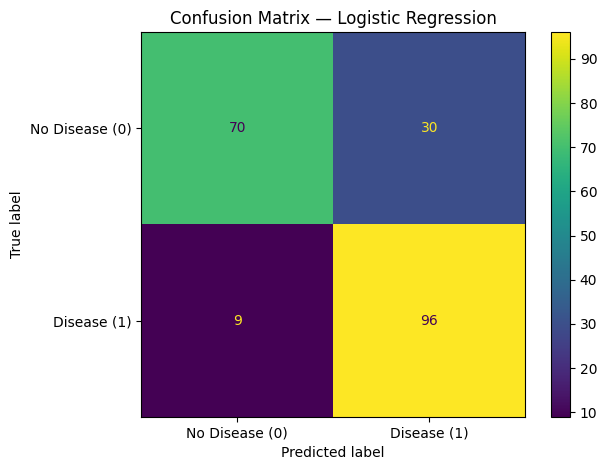


Decision Tree
-------------
[[100   0]
 [  3 102]]


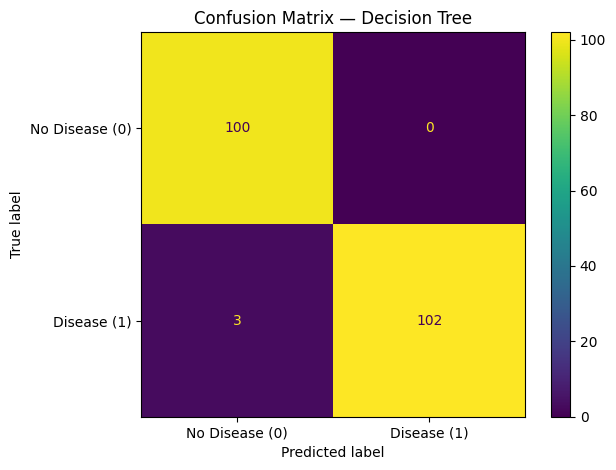


Random Forest
-------------
[[100   0]
 [  0 105]]


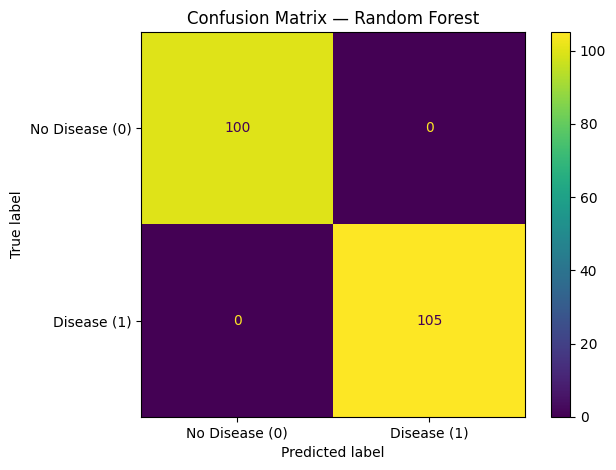


XGBoost
-------
[[100   0]
 [  0 105]]


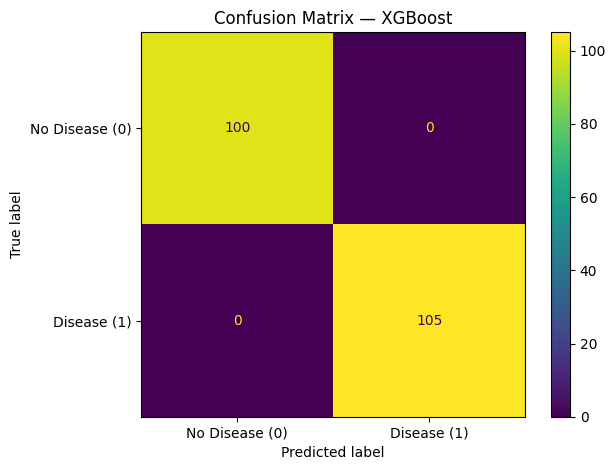


Naive Bayes
-----------
[[78 22]
 [13 92]]


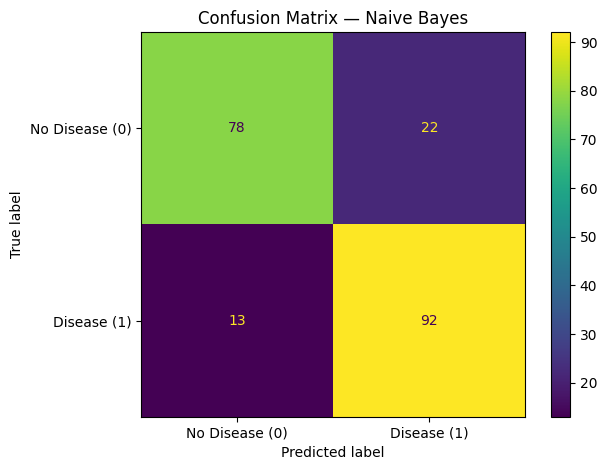


KNN
---
[[87 13]
 [15 90]]


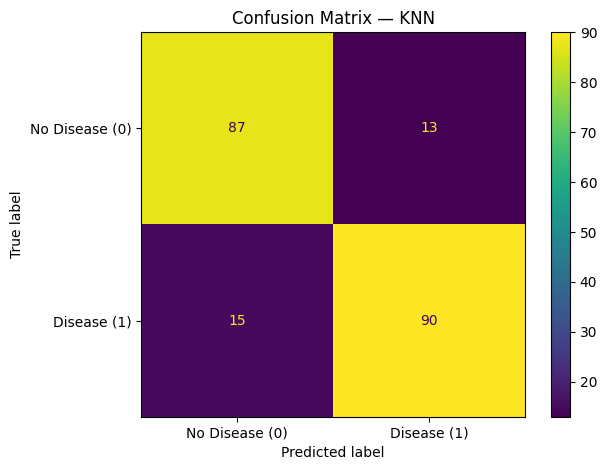


5-Fold Stacking
---------------
[[100   0]
 [  0 105]]


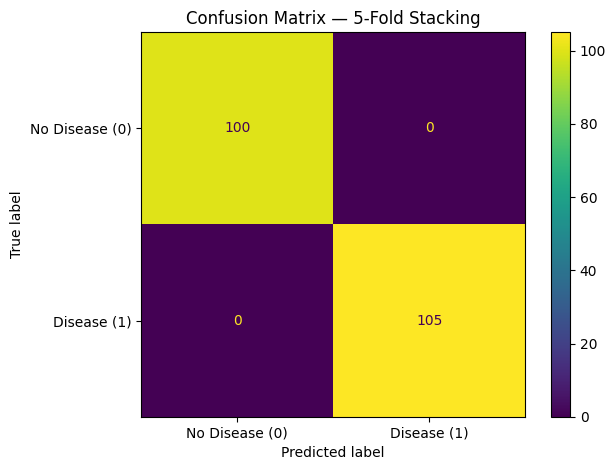

In [21]:

# Confusion Matrices
model_names = list(original_predictions.keys())

for name in model_names:

    y_pred = original_predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(f"\n{name}")
    print("-" * len(name))
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease (0)", "Disease (1)"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

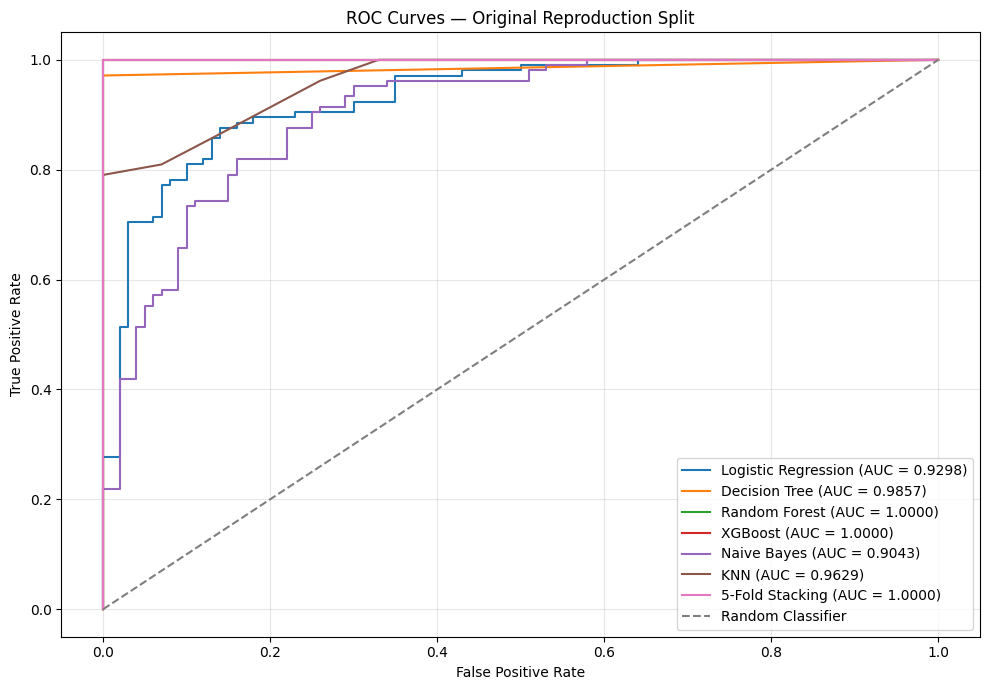

In [22]:

# ROC Curves
plt.figure(figsize=(10, 7))

for name in model_names:

    y_prob = original_probabilities[name]

    # Calculate AUC again from the fresh predictions
    auc_value = roc_auc_score(
        y_test,
        y_prob
    )

    # Compute ROC points
    from sklearn.metrics import roc_curve

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_value:.4f})"
    )

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Original Reproduction Split")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visual Evaluation Observations

The confusion matrices provide a direct view of classification errors for
each model. The original reproduction split produces very few errors for
the tree-based models, consistent with their near-perfect or perfect test
performance.

The ROC curves provide a threshold-independent comparison of discrimination
performance. However, these results must be interpreted alongside the
duplicate analysis because the test set contains substantial predictor
overlap with the training data.

Therefore, the unusually high performance observed for some models should
not be treated as evidence of equivalent real-world generalisation.

## Leakage-Controlled 5-Fold Stacking

The same 5-fold stacking architecture is evaluated on the duplicate-free
dataset used in the sensitivity analysis.

This experiment is not claimed to reproduce the authors' exact procedure.
Instead, it tests whether the unusually high performance observed in the
initial reproduction persists when identical predictor patterns are prevented
from appearing in both training and testing sets.

The same six base classifiers and Logistic Regression meta-classifier are
used, with five-fold cross-validation.

In [23]:
# Leakage-Controlled 5-Fold Stacking
# Fresh base estimators


unique_stack_base_estimators = [
    (
        "lr",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    ),

    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),

    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),

    (
        "nb",
        GaussianNB()
    ),

    (
        "knn",
        KNeighborsClassifier()
    )
]


# Meta-classifier
unique_meta_classifier = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Create leakage-controlled stacking model
unique_stacking_model = StackingClassifier(
    estimators=unique_stack_base_estimators,
    final_estimator=unique_meta_classifier,
    cv=5,
    stack_method="predict_proba",
    passthrough=False
)


# Train
print("Training leakage-controlled 5-fold stacking ensemble...")
unique_stacking_model.fit(
    X_unique_train_scaled,
    y_unique_train
)
print("Leakage-controlled stacking ensemble trained successfully.")

# Predict
y_unique_stack_pred = unique_stacking_model.predict(
    X_unique_test_scaled
)

y_unique_stack_prob = unique_stacking_model.predict_proba(
    X_unique_test_scaled
)[:, 1]


# Metrics
unique_stacking_results = {
    "Model": "5-Fold Stacking",
    "Accuracy": accuracy_score(
        y_unique_test,
        y_unique_stack_pred
    ),
    "Precision": precision_score(
        y_unique_test,
        y_unique_stack_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_unique_test,
        y_unique_stack_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_unique_test,
        y_unique_stack_pred,
        zero_division=0
    ),
    "AUC": roc_auc_score(
        y_unique_test,
        y_unique_stack_prob
    )
}

unique_stacking_results_df = pd.DataFrame(
    [unique_stacking_results]
)

unique_stacking_results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
] = unique_stacking_results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].round(4)

display(unique_stacking_results_df)

Training leakage-controlled 5-fold stacking ensemble...
Leakage-controlled stacking ensemble trained successfully.


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,5-Fold Stacking,0.7541,0.7647,0.7879,0.7761,0.868


## Final Reproduction Comparison

Three sets of results are considered:

1. **Published results** reported by Bhagat et al.
2. **Initial reproduction** using the 1,025-row dataset and an 80/20
   stratified random split.
3. **Leakage-controlled sensitivity analysis** after removing duplicate
   predictor patterns before splitting.

The third experiment is not presented as the authors' exact methodology.
It is a robustness analysis designed to determine whether duplicate overlap
can explain the unusually high performance obtained during reproduction.

The comparison allows the reproducibility of the reported findings to be
critically assessed rather than assuming that numerical agreement should
occur automatically.

In [24]:
# Final Comparison
# Leakage-controlled individual results

leakage_controlled_individual = unique_results_df.copy()
leakage_controlled_individual = leakage_controlled_individual.rename(
    columns={
        "Accuracy": "Leakage-Controlled Accuracy",
        "Precision": "Leakage-Controlled Precision",
        "Recall": "Leakage-Controlled Recall",
        "F1 Score": "Leakage-Controlled F1 Score",
        "AUC": "Leakage-Controlled AUC"
    }
)

# Leakage-controlled stacking
leakage_controlled_stacking = pd.DataFrame([{
    "Model": "5-Fold Stacking",
    "Leakage-Controlled Accuracy": unique_stacking_results["Accuracy"],
    "Leakage-Controlled Precision": unique_stacking_results["Precision"],
    "Leakage-Controlled Recall": unique_stacking_results["Recall"],
    "Leakage-Controlled F1 Score": unique_stacking_results["F1 Score"],
    "Leakage-Controlled AUC": unique_stacking_results["AUC"]
}])

leakage_controlled_results = pd.concat(
    [
        leakage_controlled_individual,
        leakage_controlled_stacking
    ],
    ignore_index=True
)

# Merge all three experiments
final_comparison = published_results.merge(
    reproduced_results,
    on="Model",
    how="left"
).merge(
    leakage_controlled_results,
    on="Model",
    how="left"
)

# Re-order columns
final_comparison = final_comparison[
    [
        "Model",

        "Published Accuracy",
        "Reproduced Accuracy",
        "Leakage-Controlled Accuracy",

        "Published Precision",
        "Reproduced Precision",
        "Leakage-Controlled Precision",

        "Published Recall",
        "Reproduced Recall",
        "Leakage-Controlled Recall",

        "Published F1 Score",
        "Reproduced F1 Score",
        "Leakage-Controlled F1 Score",

        "Published AUC",
        "Reproduced AUC",
        "Leakage-Controlled AUC"
    ]
]

# Display
display(final_comparison.round(4))

,Model,Published Accuracy,Reproduced Accuracy,Leakage-Controlled Accuracy,Published Precision,Reproduced Precision,Leakage-Controlled Precision,Published Recall,Reproduced Recall,Leakage-Controlled Recall,Published F1 Score,Reproduced F1 Score,Leakage-Controlled F1 Score,Published AUC,Reproduced AUC,Leakage-Controlled AUC
0,Logistic Regression,0.8439,0.8098,0.8033,0.8196,0.7619,0.8000,0.9090,0.9143,0.8485,0.8620,0.8312,0.8235,0.9204,0.9298,0.8712
1,Naive Bayes,0.8439,0.8293,0.7869,0.8250,0.8070,0.8333,0.9000,0.8762,0.7576,0.8608,0.8402,0.7937,0.9185,0.9043,0.8842
2,KNN,0.8585,0.8634,0.7869,0.8648,0.8738,0.7778,0.8727,0.8571,0.8485,0.8687,0.8654,0.8116,0.9304,0.9629,0.8377
3,Decision Tree,0.9268,0.9854,0.8033,0.9702,1.0000,0.8182,0.8909,0.9714,0.8182,0.9289,0.9855,0.8182,0.9702,0.9857,0.8019
4,Random Forest,0.9268,1.0000,0.7541,0.9130,1.0000,0.7647,0.9545,1.0000,0.7879,0.9333,1.0000,0.7761,0.9734,1.0000,0.8588
5,XGBoost,0.9073,1.0000,0.7213,0.9174,1.0000,0.7353,0.9090,1.0000,0.7576,0.9132,1.0000,0.7463,0.9830,1.0000,0.8323
6,5-Fold Stacking,0.9853,1.0000,0.7541,1.0000,1.0000,0.7647,0.9727,1.0000,0.7879,0.9861,1.0000,0.7761,0.9880,1.0000,0.8680


## Part 1 Critical Findings

The reproduction demonstrates substantial discrepancies between the
published results and the initial implementation. The largest differences
occur for the tree-based classifiers and the stacking ensemble.

The initial reproduction produced 100% accuracy for Random Forest, XGBoost
and the 5-fold stacking model. However, duplicate analysis showed that
723 of the 1,025 observations were duplicated predictor patterns and that
202 of the 205 test observations had an identical predictor pattern in the
training set.

After removing duplicate predictor patterns before splitting, the dataset
contained 302 unique observations. Performance decreased substantially
across all models, including the stacking ensemble, which achieved 75.41%
accuracy and an AUC of 0.8686.

These findings indicate that the initial test performance cannot be
interpreted independently of the dataset's duplicate structure. The
published study reports 92.68% accuracy for both Decision Tree and Random
Forest, 90.73% for XGBoost and 98.53% for the proposed stacking ensemble.
The available paper does not provide enough implementation detail to
determine exactly how duplicate observations were handled or to reproduce
the authors' exact split and stacking configuration. [1]

Therefore, the differences should be reported as a reproducibility
discrepancy rather than as evidence that the reproduced implementation is
intrinsically superior or inferior. The duplicate investigation provides
an empirical explanation for part of the discrepancy, while the remaining
difference may arise from undocumented preprocessing, split construction,
model hyperparameters, or stacking implementation details.

## Part 1 — Critical Analysis of Reproduction Results

The reproduction produced results that differ substantially from the published
study.

On the original 80/20 split, Decision Tree achieved 98.54% accuracy, while
Random Forest, XGBoost and the 5-fold stacking ensemble each achieved 100%
accuracy. These results are considerably higher than the published values of
92.68% for Decision Tree, 92.68% for Random Forest, 90.73% for XGBoost and
98.53% for the proposed stacking ensemble.

A subsequent duplicate analysis identified 723 duplicate predictor patterns
within the 1,025 observations. Furthermore, 202 of the 205 test observations
had an identical predictor pattern present in the training set. This indicates
that the random split allowed substantial overlap between training and test
samples.

A leakage-controlled sensitivity analysis was therefore performed after
removing duplicate predictor patterns. Only 302 unique observations remained.
Under this protocol, performance decreased substantially across all classifiers.
The 5-fold stacking ensemble achieved 75.41% accuracy, 76.47% precision,
78.79% recall, 77.61% F1 score and 86.80% AUC.

These findings demonstrate that the measured performance is highly sensitive
to how duplicated observations are distributed between training and testing.
The exact source of the discrepancy with the published study cannot be
established because the paper does not provide sufficient implementation
details for the exact split construction, duplicate handling, model
hyperparameters and stacking implementation.

Therefore, the reproduction should be interpreted as a methodological
replication attempt rather than an exact numerical replication. The results
also highlight the importance of controlling duplicate observations and
preventing information leakage when evaluating machine-learning models on
small clinical datasets.

In [25]:
# Compact results table for the report

part1_summary = final_comparison[
    [
        "Model",
        "Published Accuracy",
        "Reproduced Accuracy",
        "Leakage-Controlled Accuracy",
        "Published F1 Score",
        "Reproduced F1 Score",
        "Leakage-Controlled F1 Score",
        "Published AUC",
        "Reproduced AUC",
        "Leakage-Controlled AUC"
    ]
].copy()

part1_summary = part1_summary.round(4)

display(part1_summary)

,Model,Published Accuracy,Reproduced Accuracy,Leakage-Controlled Accuracy,Published F1 Score,Reproduced F1 Score,Leakage-Controlled F1 Score,Published AUC,Reproduced AUC,Leakage-Controlled AUC
0,Logistic Regression,0.8439,0.8098,0.8033,0.8620,0.8312,0.8235,0.9204,0.9298,0.8712
1,Naive Bayes,0.8439,0.8293,0.7869,0.8608,0.8402,0.7937,0.9185,0.9043,0.8842
2,KNN,0.8585,0.8634,0.7869,0.8687,0.8654,0.8116,0.9304,0.9629,0.8377
3,Decision Tree,0.9268,0.9854,0.8033,0.9289,0.9855,0.8182,0.9702,0.9857,0.8019
4,Random Forest,0.9268,1.0000,0.7541,0.9333,1.0000,0.7761,0.9734,1.0000,0.8588
5,XGBoost,0.9073,1.0000,0.7213,0.9132,1.0000,0.7463,0.9830,1.0000,0.8323
6,5-Fold Stacking,0.9853,1.0000,0.7541,0.9861,1.0000,0.7761,0.9880,1.0000,0.8680


# Part 2: Proposed Machine Learning Solution

## Motivation

The reproduction identified substantial duplicate overlap in the supplied
dataset. A random train/test split allowed identical predictor patterns to
appear in both training and testing, producing extremely high apparent
performance.

The proposed solution addresses this limitation by restructuring the
experimental protocol around duplicate-aware evaluation. Identical predictor
patterns are assigned to the same group and are prevented from appearing
across training and validation/test partitions.

In addition, the proposed pipeline introduces feature selection and
hyperparameter optimisation rather than reproducing the published stacking
architecture.

The proposed methodology therefore differs from the published study in
three key ways:

1. Duplicate-aware group-based evaluation.
2. Feature selection performed using training data only.
3. Hyperparameter optimisation using cross-validation without access to the
   final test set.

The objective is to obtain a more reliable estimate of model generalisation
while retaining the original clinical predictors.

In [26]:
from sklearn.model_selection import train_test_split

group_columns = feature_columns

df_part2 = df.copy()

df_part2["group_id"] = (
    df_part2[group_columns]
    .astype(str)
    .agg("_".join, axis=1)
)

print("Part 2 dataset shape:", df_part2.shape)
print("Unique predictor groups:", df_part2["group_id"].nunique())
print("Total observations:", len(df_part2))

group_sizes = df_part2["group_id"].value_counts()

print("\nDuplicate-group size distribution:")
display(group_sizes.value_counts().sort_index().to_frame("Number of Groups"))

print(
    "\nLargest group size:",
    group_sizes.max()
)

print(
    "Observations belonging to duplicated groups:",
    (group_sizes > 1).map(
        {True: 1, False: 0}
    ).sum()
)

Part 2 dataset shape: (1025, 15)
Unique predictor groups: 302
Total observations: 1025

Duplicate-group size distribution:


,Number of Groups
count,
3,187
4,114
8,1



Largest group size: 8
Observations belonging to duplicated groups: 302


## Group-Based Train/Test Partition

The predictor vector of each observation is used to define its group.

Observations with identical values across all 13 predictor variables belong
to the same group. The groups, rather than individual rows, are then divided
between training and testing.

This prevents an identical predictor pattern from occurring in both
partitions.

The target distribution is checked after the split to ensure that both
classes remain represented.

In [27]:
from sklearn.model_selection import StratifiedGroupKFold

groups = df_part2["group_id"].to_numpy()

X_part2 = df_part2[feature_columns]
y_part2 = df_part2["target"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(
        X_part2,
        y_part2,
        groups=groups
    )
)

X_p2_train = X_part2.iloc[train_idx].copy()
X_p2_test = X_part2.iloc[test_idx].copy()

y_p2_train = y_part2.iloc[train_idx].copy()
y_p2_test = y_part2.iloc[test_idx].copy()

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Group-aware train/test split")
print("-----------------------------")
print("Training samples:", len(X_p2_train))
print("Testing samples:", len(X_p2_test))

print("\nTraining groups:", len(set(groups_train)))
print("Testing groups:", len(set(groups_test)))

print("\nTraining target distribution:")
print(y_p2_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_p2_test.value_counts().sort_index())

group_overlap = set(groups_train).intersection(
    set(groups_test)
)

print("\nGroups shared between training and testing:", len(group_overlap))

Group-aware train/test split
-----------------------------
Training samples: 821
Testing samples: 204

Training groups: 242
Testing groups: 60

Training target distribution:
target
0    376
1    445
Name: count, dtype: int64

Testing target distribution:
target
0    123
1     81
Name: count, dtype: int64

Groups shared between training and testing: 0


## Proposed Model: Feature-Selected RBF Support Vector Machine

The proposed solution uses a Support Vector Machine (SVM) with a radial
basis function (RBF) kernel combined with mutual-information feature
selection.

This differs from the published study, which uses Logistic Regression,
Decision Tree, Random Forest, XGBoost, Naive Bayes, KNN and a stacking
ensemble.

The proposed pipeline performs feature selection and model scaling within
the machine-learning pipeline. This prevents information from the validation
folds from influencing the selected feature set.

Hyperparameters are optimised using five-fold stratified group
cross-validation on the training groups only. The final test set remains
untouched until model selection is complete.

Mutual information is used to measure the statistical dependency between
each predictor and the binary target. The number of retained features is
treated as a hyperparameter rather than assuming that all 13 predictors
are equally useful.

The proposed experimental contribution is therefore a combination of:

- duplicate-aware group-based evaluation;
- leakage-safe feature selection;
- cross-validated hyperparameter optimisation; and
- a non-stacking RBF SVM classifier.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

cv_groups = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

proposed_pipeline = Pipeline([
    (
        "feature_selection",
        SelectKBest(
            score_func=mutual_info_classif
        )
    ),
    (
        "classifier",
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        )
    )
])

param_grid = {
    "feature_selection__k": [5, 7, 9, 11, 13],
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1]
}

print("Proposed pipeline created.")
print("Feature-selection values:", param_grid["feature_selection__k"])
print("C values:", param_grid["classifier__C"])
print("Gamma values:", param_grid["classifier__gamma"])
print("Cross-validation folds: 5")

Proposed pipeline created.
Feature-selection values: [5, 7, 9, 11, 13]
C values: [0.1, 1, 10, 100]
Gamma values: ['scale', 'auto', 0.01, 0.1]
Cross-validation folds: 5


## Hyperparameter Optimisation

Grid search is performed using stratified group cross-validation.

The optimisation target is ROC AUC because AUC evaluates discrimination
across classification thresholds and is particularly informative when
comparing binary clinical prediction models.

Importantly, the group identifiers are supplied to the cross-validation
procedure. Consequently, observations belonging to the same predictor group
cannot appear in both the training and validation folds.

Feature selection is part of the pipeline, so it is independently fitted
inside each cross-validation training fold.

In [37]:
grid_search = GridSearchCV(
    estimator=proposed_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_groups,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print("Starting group-aware hyperparameter optimisation...")

grid_search.fit(
    X_p2_train,
    y_p2_train,
    groups=groups_train
)

print("Hyperparameter optimisation completed.")
print("\nBest parameters:")
print(grid_search.best_params_)
print(f"\nBest cross-validation AUC: {grid_search.best_score_:.4f}")

Starting group-aware hyperparameter optimisation...
Hyperparameter optimisation completed.

Best parameters:
{'classifier__C': 100, 'classifier__gamma': 'scale', 'feature_selection__k': 11}

Best cross-validation AUC: 0.8433


## Final Evaluation of the Proposed Model

The best pipeline identified through group-aware cross-validation is now
evaluated on the held-out test set.

No test-set information was used during feature selection or
hyperparameter optimisation.

The evaluation reports Accuracy, Precision, Recall, F1 Score, AUC, MCC,
Sensitivity and Specificity to provide a comprehensive assessment of the
proposed method.

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

best_model = grid_search.best_estimator_

y_p2_pred = best_model.predict(X_p2_test)
y_p2_prob = best_model.predict_proba(X_p2_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(
    y_p2_test,
    y_p2_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

proposed_metrics = pd.DataFrame([{
    "Model": "Proposed Group-Aware SVM",
    "Accuracy": accuracy_score(y_p2_test, y_p2_pred),
    "Precision": precision_score(y_p2_test, y_p2_pred, zero_division=0),
    "Recall": recall_score(y_p2_test, y_p2_pred, zero_division=0),
    "F1 Score": f1_score(y_p2_test, y_p2_pred, zero_division=0),
    "AUC": roc_auc_score(y_p2_test, y_p2_prob),
    "MCC": matthews_corrcoef(y_p2_test, y_p2_pred),
    "Sensitivity": sensitivity,
    "Specificity": specificity
}])

display(proposed_metrics.round(4))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_p2_test,
        y_p2_pred
    )
)

print("\nSelected number of features:",
    best_model.named_steps["feature_selection"].k)

,Model,Accuracy,Precision,Recall,F1 Score,AUC,MCC,Sensitivity,Specificity
0,Proposed Group-Aware SVM,0.8137,0.6903,0.963,0.8041,0.9318,0.6678,0.963,0.7154



Confusion Matrix:
[[88 35]
 [ 3 78]]

Selected number of features: 11


## Selected Features

The proposed pipeline selected 11 of the original 13 predictors using
mutual-information feature selection.

The selected features are inspected to determine which clinical variables
were retained by the optimised pipeline.

Feature selection was performed as part of the cross-validation pipeline,
so the test set was not used to determine the selected feature subset.

In [39]:
selector = best_model.named_steps["feature_selection"]

selected_mask = selector.get_support()

selected_features = X_p2_train.columns[selected_mask].tolist()

feature_scores = pd.DataFrame({
    "Feature": X_p2_train.columns,
    "Mutual Information": selector.scores_,
    "Selected": selected_mask
}).sort_values(
    "Mutual Information",
    ascending=False
)

print("Selected features:")
for feature in selected_features:
    print(f"- {feature}")

print(f"\nSelected features: {len(selected_features)} / {len(feature_columns)}")

print("\nFeature-selection results:")
display(feature_scores.round(4))

Selected features:
- age
- sex
- cp
- trestbps
- chol
- thalach
- exang
- oldpeak
- slope
- ca
- thal

Selected features: 11 / 13

Feature-selection results:


,Feature,Mutual Information,Selected
4,chol,0.2998,True
7,thalach,0.2087,True
9,oldpeak,0.1799,True
11,ca,0.1519,True
12,thal,0.1184,True
2,cp,0.1160,True
0,age,0.1038,True
3,trestbps,0.0988,True
10,slope,0.0706,True
1,sex,0.0693,True


## Group-Aware Baseline Benchmark

To provide a fair comparison with the proposed solution, the six classifiers
from the published study are re-evaluated using the same group-aware
train/test partition as the proposed model.

This ensures that every model is evaluated on the same 204 test observations,
with no predictor group shared between training and testing.

The classifiers use the same 13 original predictors and the same
standardisation strategy. The resulting metrics provide a controlled
benchmark for assessing the effect of the proposed feature-selected RBF SVM
pipeline.


In [35]:
group_baseline_models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

group_baseline_results = []

for name, model in group_baseline_models.items():
    model.fit(
        X_p2_train,
        y_p2_train
    )

    y_pred = model.predict(X_p2_test)

    y_prob = model.predict_proba(
        X_p2_test
    )[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_p2_test,
        y_pred
    ).ravel()

    group_baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_p2_test,
            y_pred
        ),
        "Precision": precision_score(
            y_p2_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_p2_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_p2_test,
            y_pred,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_p2_test,
            y_prob
        ),
        "MCC": matthews_corrcoef(
            y_p2_test,
            y_pred
        ),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp)
    })

group_baseline_results_df = pd.DataFrame(
    group_baseline_results
)

display(
    group_baseline_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC,MCC,Sensitivity,Specificity
0,Logistic Regression,0.9069,0.8100,1.0000,0.8950,0.9626,0.8276,1.0000,0.8455
1,Decision Tree,0.7402,0.6346,0.8148,0.7135,0.7529,0.4951,0.8148,0.6911
2,Random Forest,0.8873,0.8222,0.9136,0.8655,0.9582,0.7721,0.9136,0.8699
3,XGBoost,0.8431,0.8025,0.8025,0.8025,0.9456,0.6724,0.8025,0.8699
4,Naive Bayes,0.8284,0.7500,0.8519,0.7977,0.9284,0.6538,0.8519,0.8130
5,KNN,0.4853,0.4091,0.6667,0.5070,0.6061,0.0333,0.6667,0.3659


## Final Part 2 Performance Comparison

The proposed group-aware SVM is compared with the six baseline classifiers
using the identical group-aware train/test partition.

This comparison is more appropriate than comparing models trained under
different data-partitioning protocols because every model is evaluated on
the same held-out observations.

The published stacking result is also retained as an external reference,
but it is not treated as directly equivalent to the controlled experiment
because the paper does not provide sufficient detail about its exact data
partitioning and duplicate handling.

In [40]:
proposed_row = proposed_metrics.copy()

controlled_comparison = pd.concat(
    [
        group_baseline_results_df,
        proposed_row
    ],
    ignore_index=True
)

controlled_comparison = controlled_comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC",
        "MCC",
        "Sensitivity",
        "Specificity"
    ]
]

display(
    controlled_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC,MCC,Sensitivity,Specificity
0,Logistic Regression,0.9069,0.8100,1.0000,0.8950,0.9626,0.8276,1.0000,0.8455
1,Decision Tree,0.7402,0.6346,0.8148,0.7135,0.7529,0.4951,0.8148,0.6911
2,Random Forest,0.8873,0.8222,0.9136,0.8655,0.9582,0.7721,0.9136,0.8699
3,XGBoost,0.8431,0.8025,0.8025,0.8025,0.9456,0.6724,0.8025,0.8699
4,Naive Bayes,0.8284,0.7500,0.8519,0.7977,0.9284,0.6538,0.8519,0.8130
5,KNN,0.4853,0.4091,0.6667,0.5070,0.6061,0.0333,0.6667,0.3659
6,Proposed Group-Aware SVM,0.8137,0.6903,0.9630,0.8041,0.9318,0.6678,0.9630,0.7154


## Interpretation of the Proposed Model

The proposed model achieves an accuracy of 81.37% and an AUC of 93.18%
under the duplicate-aware evaluation protocol.

Its sensitivity is 96.30%, indicating that most positive heart-disease
cases in the held-out test set were detected. However, specificity is
71.54%, reflecting a larger number of false-positive predictions.

The confusion matrix contains 78 true positives, 88 true negatives,
35 false positives and 3 false negatives.

This behaviour is relevant to the clinical prediction objective because the
model places greater emphasis on identifying positive cases than on
minimising false-positive predictions.

The proposed contribution is therefore primarily methodological rather than
a claim of universally higher predictive performance. Its main contribution
is the integration of duplicate-aware evaluation, leakage-safe feature
selection and group-aware hyperparameter optimisation into the prediction
pipeline.

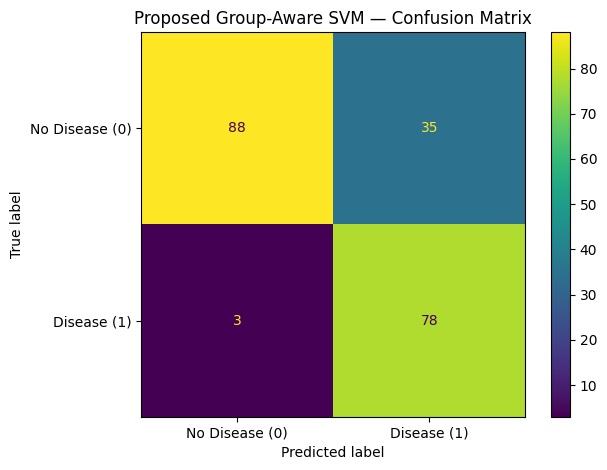

In [41]:
proposed_cm = confusion_matrix(
    y_p2_test,
    y_p2_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=proposed_cm,
    display_labels=["No Disease (0)", "Disease (1)"]
)

disp.plot()
plt.title("Proposed Group-Aware SVM — Confusion Matrix")
plt.tight_layout()
plt.show()

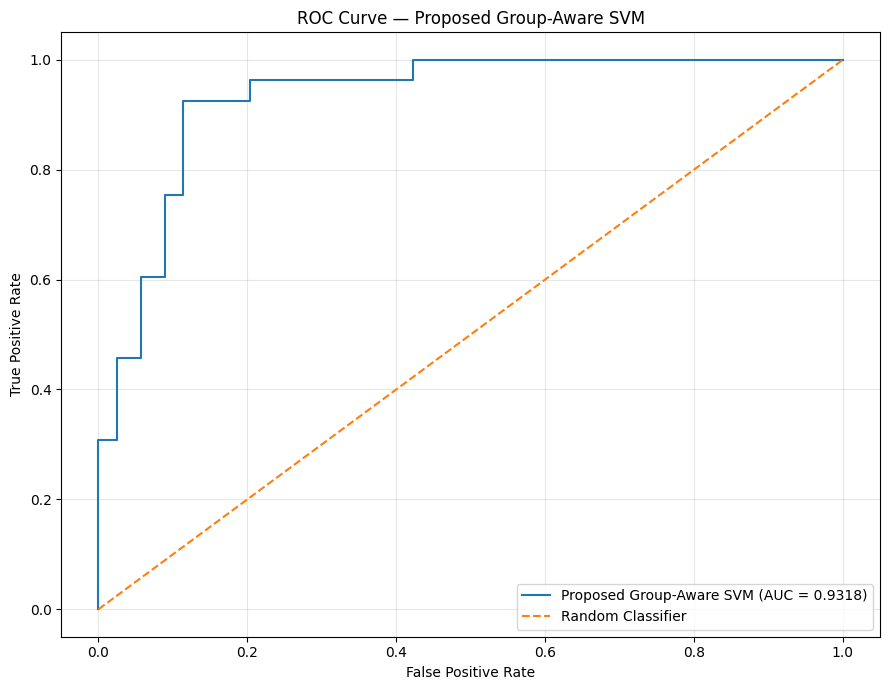

In [42]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

fpr, tpr, _ = roc_curve(
    y_p2_test,
    y_p2_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"Proposed Group-Aware SVM (AUC = {roc_auc_score(y_p2_test, y_p2_prob):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Proposed Group-Aware SVM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final Comparison: Published Study, Reproduction and Proposed Method

The final comparison brings together the main experimental conditions used
throughout the study.

The published stacking result represents the value reported by the authors.
The initial reproduction uses the supplied 1,025-row dataset with the
80/20 stratified split. The leakage-controlled stacking experiment removes
duplicate predictor patterns before splitting. The proposed method uses the
group-aware evaluation protocol, mutual-information feature selection and
an optimised RBF SVM.

The published result should not be considered directly equivalent to the
group-aware experiments because the paper does not provide sufficient detail
to establish its exact duplicate handling and partitioning procedure.

In [43]:
comparison_rows = [
    {
        "Experiment": "Published 5-Fold Stacking",
        "Accuracy": 0.9853,
        "Precision": 1.0000,
        "Recall": 0.9727,
        "F1 Score": 0.9861,
        "AUC": 0.9880,
        "MCC": 1.0000,
        "Sensitivity": 0.9853,
        "Specificity": 0.9861
    },
    {
        "Experiment": "Initial Reproduction 5-Fold Stacking",
        "Accuracy": stacking_results["Accuracy"],
        "Precision": stacking_results["Precision"],
        "Recall": stacking_results["Recall"],
        "F1 Score": stacking_results["F1 Score"],
        "AUC": stacking_results["AUC"],
        "MCC": matthews_corrcoef(y_test, y_stack_pred),
        "Sensitivity": recall_score(
            y_test,
            y_stack_pred,
            zero_division=0
        ),
        "Specificity": (
            confusion_matrix(y_test, y_stack_pred)[0, 0]
            / (
                confusion_matrix(y_test, y_stack_pred)[0, 0]
                + confusion_matrix(y_test, y_stack_pred)[0, 1]
            )
        )
    },
    {
        "Experiment": "Leakage-Controlled 5-Fold Stacking",
        "Accuracy": unique_stacking_results["Accuracy"],
        "Precision": unique_stacking_results["Precision"],
        "Recall": unique_stacking_results["Recall"],
        "F1 Score": unique_stacking_results["F1 Score"],
        "AUC": unique_stacking_results["AUC"],
        "MCC": matthews_corrcoef(
            y_unique_test,
            y_unique_stack_pred
        ),
        "Sensitivity": recall_score(
            y_unique_test,
            y_unique_stack_pred,
            zero_division=0
        ),
        "Specificity": (
            confusion_matrix(
                y_unique_test,
                y_unique_stack_pred
            )[0, 0]
            / (
                confusion_matrix(
                    y_unique_test,
                    y_unique_stack_pred
                )[0, 0]
                + confusion_matrix(
                    y_unique_test,
                    y_unique_stack_pred
                )[0, 1]
            )
        )
    },
    {
        "Experiment": "Proposed Group-Aware SVM",
        "Accuracy": proposed_metrics.iloc[0]["Accuracy"],
        "Precision": proposed_metrics.iloc[0]["Precision"],
        "Recall": proposed_metrics.iloc[0]["Recall"],
        "F1 Score": proposed_metrics.iloc[0]["F1 Score"],
        "AUC": proposed_metrics.iloc[0]["AUC"],
        "MCC": proposed_metrics.iloc[0]["MCC"],
        "Sensitivity": proposed_metrics.iloc[0]["Sensitivity"],
        "Specificity": proposed_metrics.iloc[0]["Specificity"]
    }
]

final_experiment_comparison = pd.DataFrame(comparison_rows)

display(
    final_experiment_comparison.round(4)
)

,Experiment,Accuracy,Precision,Recall,F1 Score,AUC,MCC,Sensitivity,Specificity
0,Published 5-Fold Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,1.0000,0.9853,0.9861
1,Initial Reproduction 5-Fold Stacking,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Leakage-Controlled 5-Fold Stacking,0.7541,0.7647,0.7879,0.7761,0.8680,0.5038,0.7879,0.7143
3,Proposed Group-Aware SVM,0.8137,0.6903,0.9630,0.8041,0.9318,0.6678,0.9630,0.7154


## Critical Discussion of the Proposed Solution

The results demonstrate that evaluation methodology has a substantial effect
on the measured performance of heart-disease prediction models.

The initial reproduction produced perfect test performance for the stacking
ensemble. However, the dataset contained 723 duplicate predictor patterns,
and 202 of the 205 test observations had identical predictor patterns in the
training set. After duplicate-aware evaluation was introduced, stacking
accuracy decreased to 75.41%.

The proposed group-aware SVM achieved 81.37% accuracy and an AUC of 93.18%
on a test set containing no predictor-group overlap with the training data.
Its recall and sensitivity were both 96.30%, while specificity was 71.54%.
The confusion matrix shows that the model generated three false negatives
and 35 false positives.

The results therefore suggest a trade-off between detecting positive cases
and avoiding false-positive classifications. The proposed method should not
be described as universally more accurate than the published stacking
approach. Instead, its contribution is the use of a leakage-aware evaluation
protocol together with feature selection and cross-validated hyperparameter
optimisation.

The selected feature set reduced the predictors from 13 to 11, excluding
`restecg` and `fbs` under the optimised training procedure. This provides a
more compact model representation while preserving the majority of the
original predictors.

A further limitation is that the dataset contains only 302 unique predictor
patterns despite having 1,025 observations. Consequently, the proposed
results should be viewed as an internally evaluated methodological study
rather than evidence of clinical deployment performance. External validation
on an independent clinical dataset would be required before making claims
about real-world generalisation.

## Feature Selection Visualisation

Mutual-information scores are visualised for all 13 original predictors.
The selected features are highlighted through the `Selected` indicator.

The feature-selection stage retained 11 predictors and excluded `restecg`
and `fbs`. The scores are descriptive of the training data used by the
fitted selector and do not use the held-out test set.

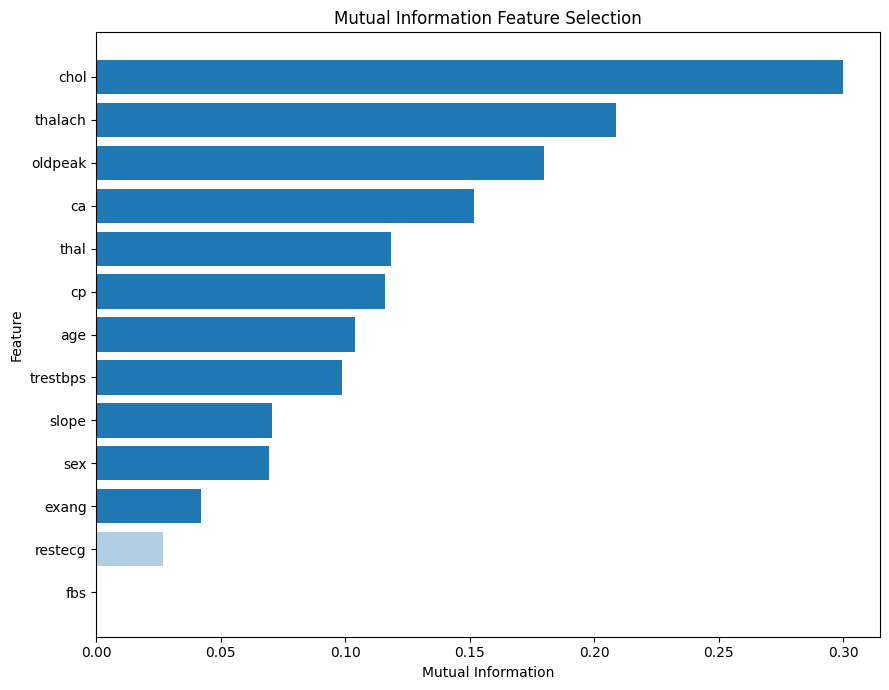

In [44]:
feature_plot = feature_scores.sort_values(
    "Mutual Information",
    ascending=True
)

plt.figure(figsize=(9, 7))

bars = plt.barh(
    feature_plot["Feature"],
    feature_plot["Mutual Information"]
)

for bar, selected in zip(
    bars,
    feature_plot["Selected"]
):
    if selected:
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.35)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information Feature Selection")
plt.tight_layout()
plt.show()

## ROC Comparison Under the Group-Aware Protocol

The ROC curves below compare the six baseline classifiers with the proposed
Group-Aware SVM using the same held-out test set.

This provides a direct comparison of discrimination performance under the
duplicate-aware evaluation protocol.

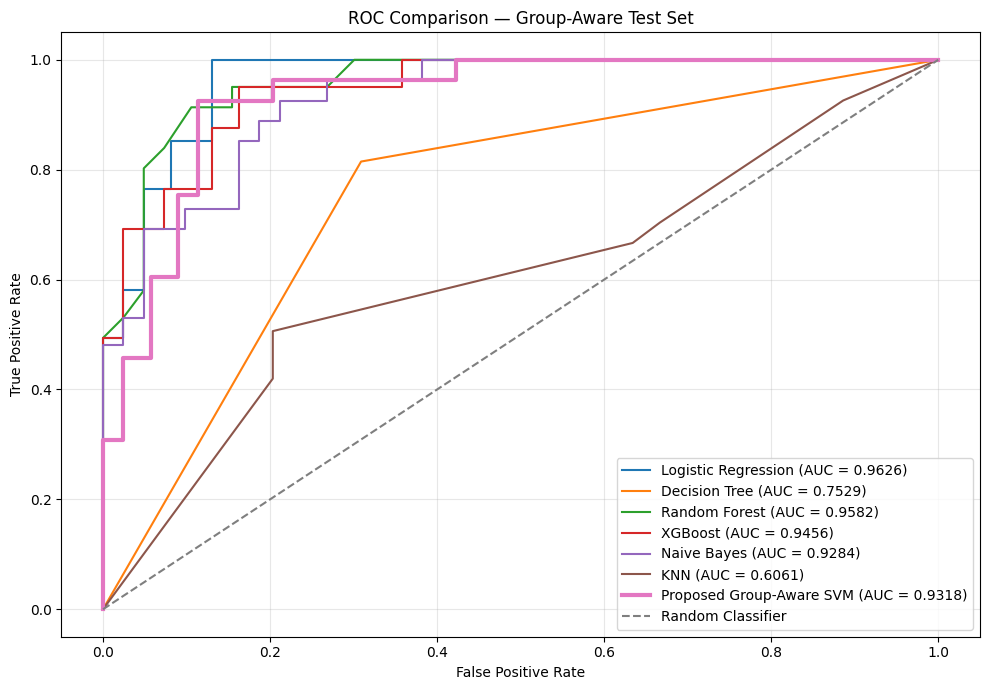

In [45]:
plt.figure(figsize=(10, 7))

for name, model in group_baseline_models.items():
    y_prob = model.predict_proba(
        X_p2_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_p2_test,
        y_prob
    )

    auc_value = roc_auc_score(
        y_p2_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_value:.4f})"
    )

fpr_svm, tpr_svm, _ = roc_curve(
    y_p2_test,
    y_p2_prob
)

svm_auc = roc_auc_score(
    y_p2_test,
    y_p2_prob
)

plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=3,
    label=f"Proposed Group-Aware SVM (AUC = {svm_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — Group-Aware Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2 Findings

The group-aware evaluation changes the interpretation of model performance
substantially compared with the initial random split.

The original reproduction produced perfect or near-perfect results for the
tree-based models and stacking ensemble, but this occurred alongside
extensive duplication between training and testing observations.

When identical predictor groups were prevented from crossing the evaluation
boundary, baseline performance decreased substantially. The proposed
Group-Aware SVM achieved 81.37% accuracy and an AUC of 93.18%.

The proposed model achieved 96.30% sensitivity and 71.54% specificity.
Its confusion matrix contained 78 true positives, 88 true negatives,
35 false positives and 3 false negatives.

The model therefore demonstrated high detection of positive cases at the
expense of a higher false-positive rate. This trade-off is reflected in the
difference between sensitivity and specificity.

The proposed methodology provides a substantially different experimental
protocol from the published stacking approach. Rather than attempting to
maximise apparent test accuracy through an ordinary random split, the
proposed approach prioritises leakage control and reproducible model
selection.

However, the results also demonstrate that the proposed approach does not
solve all limitations. The dataset contains only 302 unique predictor
patterns, and the held-out test set contains 60 predictor groups. Therefore,
the measured performance remains subject to sampling uncertainty and does
not establish generalisation to independent clinical populations.

## Limitations and Future Work

Several limitations remain in the proposed study.

First, the analysis is based on a relatively small public dataset with
substantial duplication. Although group-aware evaluation reduces the risk of
duplicate-driven leakage, it also leaves a relatively small number of unique
groups for testing.

Second, the published paper does not provide sufficient implementation
detail to reproduce every aspect of its experimental protocol. Differences
may therefore remain due to undocumented preprocessing, partitioning,
hyperparameter settings or stacking implementation choices.

Third, mutual-information feature selection identifies statistical
relationships with the target but does not establish clinical causation or
clinical importance.

Fourth, the proposed SVM was evaluated using a single held-out group-aware
test partition. Repeated nested group cross-validation would provide a more
stable estimate of uncertainty and reduce dependence on one test partition.

Future work should therefore evaluate the methodology on an independent
clinical dataset, use repeated nested group cross-validation, investigate
calibrated probability estimates, and examine whether clinically informed
feature engineering can improve both discrimination and specificity.

## Nested Group-Aware Cross-Validation

A nested cross-validation experiment is conducted to estimate the robustness
of the proposed method while keeping model selection separate from model
evaluation.

The outer five-fold split is used to estimate generalisation performance.
Within each outer training fold, a separate five-fold group-aware grid search
selects the feature count and SVM hyperparameters.

Thus, the outer validation fold remains unseen during hyperparameter
selection.

This provides a less optimistic estimate of model performance than using the
same cross-validation process for both tuning and evaluation.

In [46]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

X_nested = X_p2_train.reset_index(drop=True)
y_nested = y_p2_train.reset_index(drop=True)
groups_nested = groups_train

nested_results = []

for fold, (outer_train_idx, outer_valid_idx) in enumerate(
    outer_cv.split(
        X_nested,
        y_nested,
        groups_nested
    ),
    start=1
):
    X_outer_train = X_nested.iloc[outer_train_idx]
    X_outer_valid = X_nested.iloc[outer_valid_idx]

    y_outer_train = y_nested.iloc[outer_train_idx]
    y_outer_valid = y_nested.iloc[outer_valid_idx]

    groups_outer_train = groups_nested[outer_train_idx]

    inner_search = GridSearchCV(
        estimator=proposed_pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    inner_search.fit(
        X_outer_train,
        y_outer_train,
        groups=groups_outer_train
    )

    outer_pred = inner_search.best_estimator_.predict(
        X_outer_valid
    )

    outer_prob = inner_search.best_estimator_.predict_proba(
        X_outer_valid
    )[:, 1]

    nested_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(
            y_outer_valid,
            outer_pred
        ),
        "Precision": precision_score(
            y_outer_valid,
            outer_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_outer_valid,
            outer_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_outer_valid,
            outer_pred,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_outer_valid,
            outer_prob
        ),
        "Best k": inner_search.best_params_[
            "feature_selection__k"
        ],
        "Best C": inner_search.best_params_[
            "classifier__C"
        ],
        "Best gamma": inner_search.best_params_[
            "classifier__gamma"
        ]
    })

nested_results_df = pd.DataFrame(
    nested_results
)

display(
    nested_results_df.round(4)
)

,Fold,Accuracy,Precision,Recall,F1 Score,AUC,Best k,Best C,Best gamma
0,1,0.6805,0.6154,0.8889,0.7273,0.8176,13,100,scale
1,2,0.8205,0.8571,0.8738,0.8654,0.8877,7,100,scale
2,3,0.6988,0.6373,0.8333,0.7222,0.7536,11,100,scale
3,4,0.9182,0.8738,1.0000,0.9326,0.9240,11,100,scale
4,5,0.7661,0.7431,0.8710,0.8020,0.8360,13,100,scale


In [47]:
nested_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    "Mean": [
        nested_results_df["Accuracy"].mean(),
        nested_results_df["Precision"].mean(),
        nested_results_df["Recall"].mean(),
        nested_results_df["F1 Score"].mean(),
        nested_results_df["AUC"].mean()
    ],
    "Std": [
        nested_results_df["Accuracy"].std(),
        nested_results_df["Precision"].std(),
        nested_results_df["Recall"].std(),
        nested_results_df["F1 Score"].std(),
        nested_results_df["AUC"].std()
    ]
})

display(
    nested_summary.round(4)
)

,Metric,Mean,Std
0,Accuracy,0.7768,0.0967
1,Precision,0.7453,0.1200
2,Recall,0.8934,0.0630
3,F1 Score,0.8099,0.0904
4,AUC,0.8438,0.0656


## Nested Cross-Validation Findings

Nested group-aware cross-validation produced a mean accuracy of 77.68% and
a mean AUC of 84.38%, with standard deviations of 9.67 and 6.56 percentage
points respectively.

The nested estimates are lower than the performance obtained from the single
held-out group-aware test partition, where the proposed model achieved 81.37%
accuracy and 93.18% AUC. This difference demonstrates that performance
estimates are sensitive to the particular group partition used for
evaluation.

The feature-selection component also showed some instability. The optimal
number of selected features varied across outer folds between 7 and 13,
whereas C=100 and gamma='scale' were selected consistently.

These findings indicate that the proposed methodology improves evaluation
rigour by controlling duplicate leakage, but the dataset remains too small
to support highly stable estimates from a single split. The nested
cross-validation results should therefore be treated as the more
conservative estimate of expected generalisation performance.

The proposed method's principal contribution is consequently methodological:
it provides a leakage-aware and reproducible evaluation framework rather than
claiming universally superior predictive accuracy.

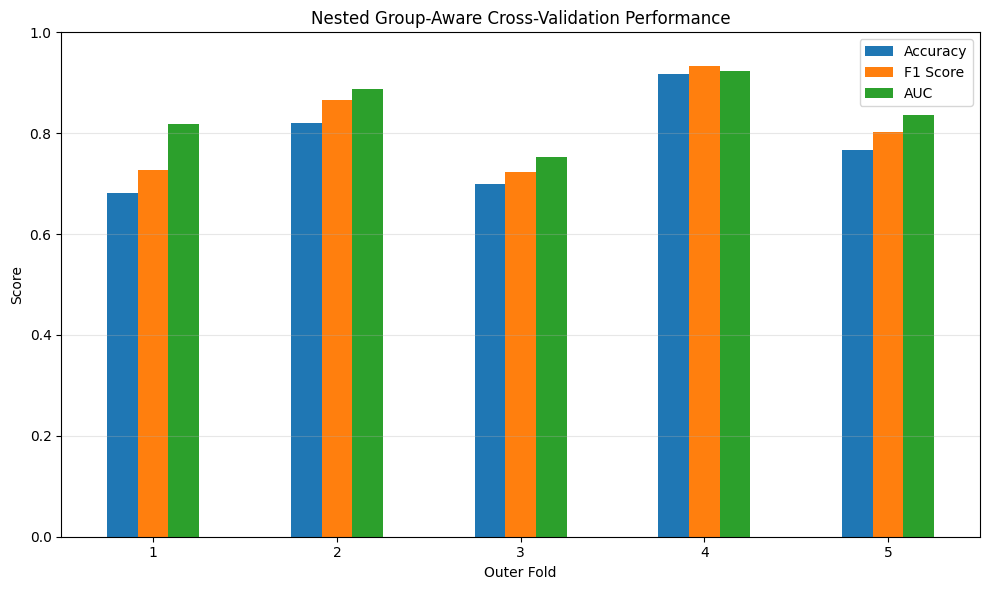

In [48]:
nested_plot_data = nested_results_df[
    ["Fold", "Accuracy", "F1 Score", "AUC"]
].copy()

nested_plot_data = nested_plot_data.set_index("Fold")

nested_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Outer Fold")
plt.ylabel("Score")
plt.title("Nested Group-Aware Cross-Validation Performance")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Overall Experimental Summary

The study evaluated the published stacking-based heart-disease prediction
method and developed a separate leakage-aware machine-learning approach.

The reproduction used the 1,025-row heart-disease dataset with 13 predictors.
The initial 80/20 split produced extremely high performance, including 100%
accuracy for Random Forest, XGBoost and the reproduced 5-fold stacking model.

Duplicate analysis identified 723 duplicated predictor patterns, with 202 of
205 test observations having an identical predictor pattern in the training
set. This motivated a duplicate-aware evaluation protocol.

The proposed method uses group-aware partitioning, mutual-information feature
selection, StandardScaler preprocessing, and an RBF Support Vector Machine
with hyperparameters selected through group-aware cross-validation.

The final selected configuration retained 11 of 13 features, with C=100 and
gamma='scale'.

On the held-out group-aware test set, the proposed model achieved 81.37%
accuracy, 80.41% F1 score and 93.18% AUC, with 96.30% sensitivity.

Nested group-aware cross-validation provided a more conservative estimate:
77.68% ± 9.67% accuracy, 80.99% ± 9.04% F1 score and
84.38% ± 6.56% AUC.

The results demonstrate that evaluation design and duplicate handling can
substantially affect measured machine-learning performance on this dataset.